In [3]:
from qpe import *

from time import time

from scipy.stats import unitary_group, gaussian_kde

from time import sleep
from multiprocessing import Pool

from numpy import log
from numpy.random import permutation
from itertools import permutations
from sympy.combinatorics.permutations import Permutation
from math import factorial
from scipy import sparse

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('text', usetex=True)

In [4]:
def log3(a):
    return log(a)/log(3)

In [5]:
def train_obs(labels, ansatz, dms=None, L=None, S=None, n_copies=1, method="BFGS", w_ls=1e0, w_var=1e-4, x0=None, options={}, save_data=False, file_name=None, fvals=[]):

    n_pars = len(ansatz)
    n_train = len(labels)
            
    if L is None and S is None:
        n_inp = int(log3(len(dms[0])))
        n_tot = n_inp*n_copies
        time_start = time()
        dms_cop = zeros([n_train, 3**n_tot, 3**n_tot], dtype=complex)
        for i in range(n_train):
            dms_cop[i] = reduce(kron, [dms[i]]*n_copies)
        L = zeros((n_train, n_pars))
        S = zeros((n_train, n_pars, n_pars))
        for i in range(n_train):
            print("Computing L and S: i=%d" %i, end="\r")
            for j in range(n_pars):
                op_loc = dms_cop[i]@ansatz[j]
                L[i][j] = trace(op_loc).real
                for k in range(n_pars):
                    R[i][j][k] = trace(op_loc@ansatz[k]).real
        time_finish = time() - time_start
        print("Computing L and S: completed in %.2f s" %time_finish, end="\r")
    
    fval_cont = [0]
    def fun(x):
        expecs = array([x@L[i] for i in range(n_train)])
        disps = array([x@S[i]@x for i in range(n_train)]) - expecs**2
        f = w_ls*np.sum((array(expecs) - array(labels))**2)
        f += w_var*np.sum(array(disps))
        fval_cont[0] = f
        return f
    
    if save_data == True and file_name is None:
        file_name = "c=%d-m=%d=l=%d-w_ls=%f-w_var=%f-n_train=%d" %(n_copies, w_ls, w_var, n_train)
        
    time_loc = time()
    
    def callback(x):
        fvals.append(fval_cont[0])
        print("\t\t\tIteration: %d | Cost: %.8f | Time passed: %d s" %(len(fvals), fval_cont[0], time() - time_loc), end="\r")
        if save_data == True:
            np.save(file_name + "-pars", x)
            np.save(file_name + "-fvals", fvals)
        return None
    
    if method in ["Nelder-Mead", "L-BFGS-B", "SLSQP", "TNC", "Powell", "COBYLA", "COBYQA"]:
        bounds = [(-100, 100)]*n_pars # some arbitrary values 
    else:
        bounds = None
    if x0 is None:
        x0 = normal(0, 1e-5, n_pars)
    
    optimization_result = minimize(fun=fun, x0=x0, bounds=bounds, method=method, callback=callback, options=options) # "maxiter": int(1e10)

    return fvals, optimization_result

In [7]:
def train_obs_L(labels, ansatz, L, n_copies=1, method="BFGS", x0=None, options={}, save_data=False, file_name=None, fvals=[]):

    n_pars = len(ansatz)
    n_train = len(labels)
    
    fval_cont = [0]
    def fun(x):
        expecs = array([x@L[i] for i in range(n_train)])
        f = np.sum((array(expecs) - array(labels))**2)
        fval_cont[0] = f
        return f
    
    if save_data == True and file_name is None:
        file_name = "c=%d-m=%d=l=%d-w_ls=%f-w_var=%f-n_train=%d" %(n_copies, w_ls, w_var, n_train)
        
    time_loc = time()
    
    def callback(x):
        fvals.append(fval_cont[0])
        print("\t\t\tIteration: %d | Cost: %.8f | Time passed: %d s" %(len(fvals), fval_cont[0], time() - time_loc), end="\r")
        if save_data == True:
            np.save(file_name + "-pars", x)
            np.save(file_name + "-fvals", fvals)
        return None
    
    if method in ["Nelder-Mead", "L-BFGS-B", "SLSQP", "TNC", "Powell", "COBYLA", "COBYQA"]:
        bounds = [(-100, 100)]*n_pars # some arbitrary values 
    else:
        bounds = None
    if x0 is None:
        x0 = normal(0, 1e-5, n_pars)
    
    optimization_result = minimize(fun=fun, x0=x0, bounds=bounds, method=method, callback=callback, options=options) # "maxiter": int(1e10)

    return fvals, optimization_result

In [8]:
def swap_matrix(n_qudits, q1, q2, dim=2):
    """
       Can be rewritten as a sparse matrix.
       Optimizable! Use fast kron with the identity, kron_A_N and kron_N_A.
    """
    p1, p2 = sorted([q1, q2])
    SW = zeros([dim**n_qudits, dim**n_qudits])
    SW_ph = zeros([dim, dim])
    for i in range(dim):
        for j in range(dim):
            SW_ph[[i], [j]] = 1
            SW_ij = array(SW_ph)
            SW_ph[[i], [j]] = 0
            SW_ph[[j], [i]] = 1
            SW_ji = array(SW_ph)
            SW_ph[[j], [i]] = 0
            op = reduce(kron, [eye(dim**p1), SW_ij, eye(dim**(p2 - p1 - 1)), SW_ji, eye(dim**(n_qudits - p2 - 1))])
            SW += op    
    return SW

def swap_matrix_sparse(n_qudits, q1, q2, dim=2):
    p1, p2 = sorted([q1, q2])
    SW = sparse.csr_array(zeros([dim**n_qudits, dim**n_qudits]))
    SW_ph = zeros([dim, dim])
    for i in range(dim):
        for j in range(dim):
            SW_ph[i, j] = 1
            SW_ij = array(SW_ph)
            SW_ph[i, j] = 0
            SW_ph[j, i] = 1
            SW_ji = array(SW_ph)
            SW_ph[j, i] = 0
            op = reduce(sparse.kron, [sparse.eye(dim**p1), SW_ij, sparse.eye(dim**(p2 - p1 - 1)), SW_ji, sparse.eye(dim**(n_qudits - p2 - 1))])
            SW += op    
    return SW

In [9]:
def aux_info(dms, labels, pars, ansatz, n_copies=1):

    n_inp = int(log3(len(dms[0])))
    n_tot = n_inp*n_copies
    n_pars = len(ansatz)
    n_data = len(labels)

    H = sum([par*op for par, op in zip(pars, ansatz)])
    H_sq = H@H
    
    # dms_cop = zeros([n_data, 3**n_tot, 3**n_tot], dtype=complex)
    # for i in range(n_data):
    #     dms_cop[i] = reduce(kron, [dms[i]]*n_copies)
    # expecs = array([trace(H@dm).real for dm in dms_cop])
    # disps = array([trace(H_sq@dm).real for dm in dms_cop]) - expecs**2

    ### slower (?), but less memory-intensive ###
    expecs = zeros(n_data)
    disps = zeros(n_data)
    for i in range(n_data):
        print("\t\tInferring: i =", i, end="\r")
        dm_c = reduce(kron, [dms[i]]*n_copies)
        expecs[i] = trace(H@dm_c).real
        disps[i] = trace(H_sq@dm_c).real
    
    return expecs, disps

#### Training data and settings

In [10]:
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
def i_to_j(string):
    new_str='';
    for s in string:
        if s=='i':
            new_str+='j'
        else:
            new_str+=s
    return new_str
def reading_data(file='qutrit_results.csv'):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file)
    
    dfvals = [[complex(i_to_j(cell)) for cell  in row] for row in df.values]
    dms=[]
    labels=[]
    for row in dfvals:
        labels.append(row[0].real)
        dms.append(np.array(row)[1:82].reshape(9,9))
    return labels, dms

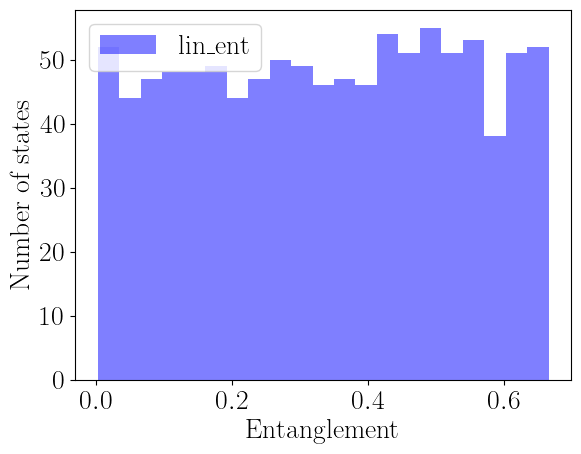

In [11]:
labels_train, dms_train=reading_data('qutrits_mixed_train.csv')
plt.hist(labels_train, bins=21, alpha=0.5, label="lin_ent", color="blue")
# plt.hist(negs, bins=101, alpha=0.5, label="negativity", color="green")
plt.xlabel("Entanglement")
plt.ylabel("Number of states")
# plt.xlim(0, 1)
# plt.ylim(1e-1)
plt.legend()
# plt.yscale("log")
plt.show()

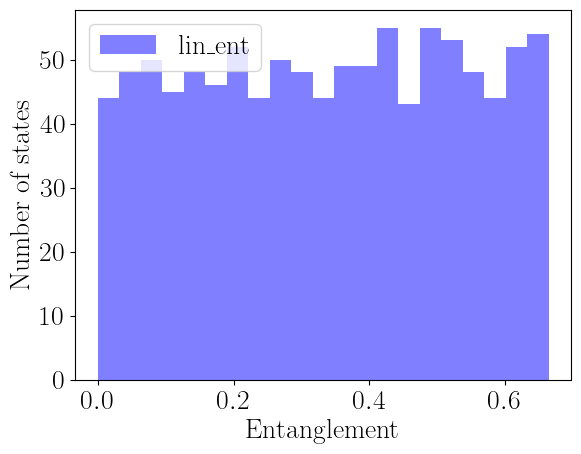

In [12]:
labels_test, dms_test=reading_data('qutrits_mixed_test.csv')
plt.hist(labels_test, bins=21, alpha=0.5, label="lin_ent", color="blue")
# plt.hist(negs, bins=101, alpha=0.5, label="negativity", color="green")
plt.xlabel("Entanglement")
plt.ylabel("Number of states")
# plt.xlim(0, 1)
# plt.ylim(1e-1)
plt.legend()
# plt.yscale("log")
plt.show()

In [13]:
n_inp = 2
n_train = len(dms_train)#1000
n_test = len(dms_test)#1000
mixed = True
marks = "neg"
eps = 1e-3

# dms_train, labels_train = gen_even_ent_data(n_train, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
# dms_test, labels_test = gen_even_ent_data(n_test, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
        
# purities_test = [trace(dm@dm).real for dm in dms_test]

In [14]:
n_copies = 4
n_tot = n_inp*n_copies
w_ls = 1e0
w_var = 1e-4
method = "BFGS"
options = {"maxiter": int(1e4)}#, "maxfun": int(1e10)}#

In [12]:
# path = r"/home/kardashin/Work/Quantum channel estimation/Results/Entanglement/Negativity/"
# info = "T=%d-w_ls=%f-w_var=%f-marks=%s-mixed=%s" %(n_train, w_ls, w_var, marks, mixed)

# $L$ and $S$

#### Ansatzes

In [13]:
# """ All 4^n Pauli matrices"""
# # Complicated? Saves RAM!
# n_pars = 4**n_tot
# ansatz = zeros([4**n_tot, 2**n_tot, 2**n_tot], dtype=complex)
# pauli_string_generator = product([I, X, Y, Z], repeat=n_tot)
# for i in range(4**n_tot):
#     ansatz[i] = reduce(kron, next(pauli_string_generator))

In [14]:
# """ Pairs of swaps """
# n_pars = int(n_tot*(n_tot - 1)/2) + 1
# c = 0
# ansatz = zeros([n_pars, 2**n_tot, 2**n_tot], dtype=complex)
# for i in range(n_tot):
#     for j in range(i):
#         ansatz[c] = swap_matrix(n_tot, i, j)
#         c += 1
# ansatz[-1] = eye(2**n_tot)

In [15]:
# """ Experimental: Projector onto the symmetric subspace, see Eqs. 4 and 5 in https://arxiv.org/abs/1702.03528 """
# ansatz = []
# for perm in permutations([i for i in range(n_tot)], n_tot):
#     P = zeros([2**n_tot, 2**n_tot], dtype=complex)
#     for transp in Permutation(perm).transpositions():
#         P = P + swap_matrix(n_tot, transp[0], transp[1])
#     ansatz.append(P/factorial(n_tot))
# n_pars = len(ansatz)

In [16]:
"""Some swaps"""

dim = 3

ansatz = []

ansatz.append(sparse.eye(dim**n_tot))

# (i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 4, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 5, 7, dim=dim))

# (i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 3, 7, dim=dim))

# (i, i+6)
ansatz.append(swap_matrix_sparse(n_tot, 0, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 7, dim=dim))

# # (i, i+2)*(i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))

# # (i, i+4)*(i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 2, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 5, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))

# (i, i+6)*(i, i+6)
ansatz.append(swap_matrix_sparse(n_tot, 0, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 7, dim=dim)) # this

# (i, i+2)*(i, i+2)*(i, i+2)*(i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim)@swap_matrix_sparse(n_tot, 4, 6, dim=dim)@swap_matrix_sparse(n_tot, 5, 7, dim=dim))

# (i, i+4)*(i, i+4)*(i, i+4)*(i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim)@swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))


n_pars = len(ansatz)
n_pars

31

#### Compute $L$ and $S$

In [17]:
from numpy.random import permutation

In [18]:
labels_train = array(labels_train)
labels_test = array(labels_test)
dms_train = array(dms_train)
dms_test = array(dms_test)

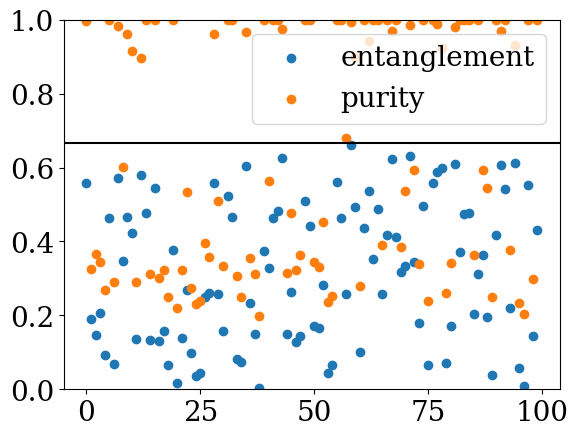

In [19]:
perm_train = permutation(len(labels_train))
perm_test = permutation(len(labels_test))

n_train_trunc = 100
n_test_trunc = 1000

labels_train_trunc = labels_train[perm_train][:n_train_trunc]
labels_test_trunc = labels_test[perm_test][:n_test_trunc]
dms_train_trunc = dms_train[perm_train][:n_train_trunc]
dms_test_trunc = dms_test[perm_test][:n_test_trunc]

plt.scatter(arange(n_train_trunc), labels_train_trunc, label="entanglement")
plt.scatter(arange(n_train_trunc), [trace(dm@dm).real for dm in dms_train_trunc], label="purity")
plt.axhline(2/3, color="black")
plt.ylim(0, 1)
plt.legend()

In [46]:
""" parallel """

def compute_LS_i(i):
    sleep(i/50) # for pretty printing
    print("Computing L and S: i =", i)
    L_i = zeros(n_pars)
    S_i = zeros([n_pars, n_pars])
    dm_train_c = reduce(kron, [dms_train[i]]*n_copies)
    for j in range(n_pars):
        op_loc = dm_train_c@ansatz[j]
        L_i[j] = trace(op_loc).real
        for k in range(n_pars):
            S_i[j][k] = trace(op_loc@ansatz[k]).real
    return L_i, S_i

if __name__ == '__main__':
    time_start = time()
    L = zeros((n_train_trunc, n_pars))
    S = zeros((n_train_trunc, n_pars, n_pars))
    with Pool() as pool: 
        LS_i_list = pool.map(compute_LS_i, [i for i in range(n_train_trunc)])
    time_finish = time() - time_start
    print("Computing L and S: completed in %.2f s" %time_finish, end="\r")

Computing Q and R: i = 0
Computing Q and R: i = 5
Computing Q and R: i = 10
Computing Q and R: i = 15
Computing Q and R: i = 20
Computing Q and R: i = 25
Computing Q and R: i = 21
Computing Q and R: i = 26
Computing Q and R: i = 16
Computing Q and R: i = 1
Computing Q and R: i = 11
Computing Q and R: i = 6
Computing Q and R: i = 27
Computing Q and R: i = 22
Computing Q and R: i = 12
Computing Q and R: i = 2
Computing Q and R: i = 7
Computing Q and R: i = 17


KeyboardInterrupt: 

In [28]:
# """ sequential """
# time_start = time()
# L = zeros((n_train, n_pars))
# S = zeros((n_train, n_pars, n_pars))
# for i in range(n_train):
#     print("Computing L and S: i=%d" %i, end="\r")
#     dm_train_c = reduce(kron, [dms_train[i]]*n_copies)
#     for j in range(n_pars):
#         op_loc = dm_train_c@ansatz[j]
#         Q[i][j] = trace(op_loc).real
#         for k in range(n_pars):
#             print("Computing L and S: i=%d | j=%d | k=%d" %(i, j, k), end="\r")
#             S[i][j][k] = trace(op_loc@ansatz[k]).real
# time_finish = time() - time_start
# print("Computing L and S: completed in %.2f s" %time_finish, end="\r")

In [ ]:
time_start = time()
fvals, result = train_obs(dms_train, labels_train, ansatz, L=L, S=S,
                          n_copies=n_copies, x0=None, method=method, w_ls=w_ls, w_var=w_var, options=options, save_data=False, file_name=None)
time_finish = time() - time_start
print("\n\nFinished in", time_finish)
print("Cost:", result.fun)
print(result.message)
pars = result.x

			Iteration: 15 | Cost: 2.42011045 | Time passed: 0 ss

Finished in 0.22182297706604004
Cost: 2.4201104483859814
Optimization terminated successfully.


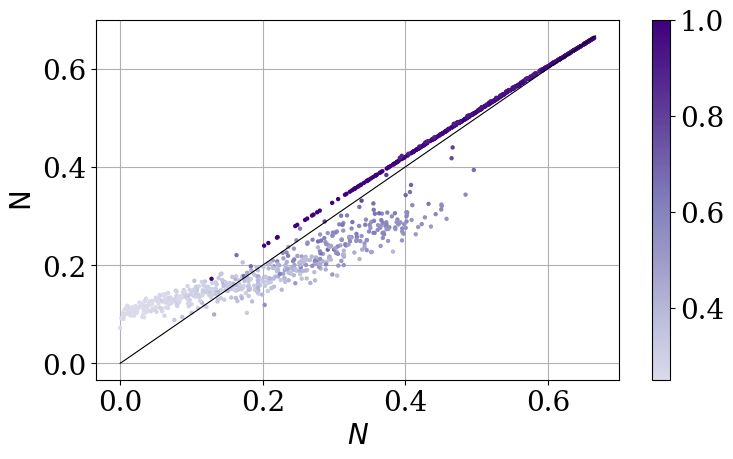

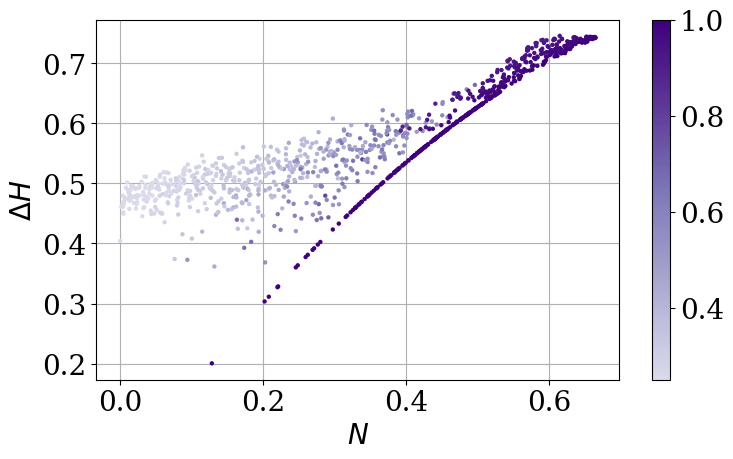

In [25]:


expecs_train, disps_train, H = aux_info(dms_train, labels_train, pars, ansatz, n_copies=n_copies)
expecs_test, disps_test, H = aux_info(dms_test, labels_test, pars, ansatz, n_copies=n_copies)


cmap_name = "Purples"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.25, 1., cmap.N))
cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

plt.figure(figsize=(8, 5))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_test, expecs_test, c=purities_test, cmap=cmap, s=10, edgecolor='none') # , color="dodgerblue"
#plt.scatter(labels_test, expecs_test, s=10, edgecolor='none')
plt.plot(linspace(0, 2/3), linspace(0, 2/3), linestyle="-", linewidth=0.8, color="black")
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathsf{N}$")
# plt.title(r"$c = %d$, $l = %d$, $E = %f$" %(n_copies, n_layers, sum_err_test))
plt.colorbar()
plt.clim(1/(dim**n_inp)**2, 1)
plt.grid()
plt.tight_layout()
# plt.savefig(save_path + file_info + "-random_mixed-qbq-pred-test-fin.pdf", bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_test, disps_test, c=purities_test, cmap=cmap, s=10, edgecolor='none')
plt.xlabel(r"$N$")
plt.ylabel(r"$\Delta H$")
# plt.title(r"$c = %d$, $l = %d$, $E = %f$" %(n_copies, n_layers, sum_err_test))
plt.colorbar()
plt.clim(1/(dim**n_inp)**2, 1)
plt.grid()
plt.tight_layout()
# plt.savefig(save_path + file_info + "-random_mixed-qbq-var-test-fin.pdf", bbox_inches='tight')
plt.show()

# Only $L$

#### Ansatzes

In [13]:
# """ All 4^n Pauli matrices"""
# # Complicated? Saves RAM!
# n_pars = 4**n_tot
# ansatz = zeros([4**n_tot, 2**n_tot, 2**n_tot], dtype=complex)
# pauli_string_generator = product([I, X, Y, Z], repeat=n_tot)
# for i in range(4**n_tot):
#     ansatz[i] = reduce(kron, next(pauli_string_generator))

In [14]:
# """ Pairs of swaps """
# n_pars = int(n_tot*(n_tot - 1)/2) + 1
# c = 0
# ansatz = zeros([n_pars, 2**n_tot, 2**n_tot], dtype=complex)
# for i in range(n_tot):
#     for j in range(i):
#         ansatz[c] = swap_matrix(n_tot, i, j)
#         c += 1
# ansatz[-1] = eye(2**n_tot)

In [15]:
# """ Experimental: Projector onto the symmetric subspace, see Eqs. 4 and 5 in https://arxiv.org/abs/1702.03528 """
# ansatz = []
# for perm in permutations([i for i in range(n_tot)], n_tot):
#     P = zeros([2**n_tot, 2**n_tot], dtype=complex)
#     for transp in Permutation(perm).transpositions():
#         P = P + swap_matrix(n_tot, transp[0], transp[1])
#     ansatz.append(P/factorial(n_tot))
# n_pars = len(ansatz)

In [15]:
"""Some swaps"""

dim = 3

ansatz = []

ansatz.append(sparse.eye(dim**n_tot))

# (i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 4, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 5, 7, dim=dim))

# (i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 3, 7, dim=dim))

# (i, i+6)
ansatz.append(swap_matrix_sparse(n_tot, 0, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 7, dim=dim))

# # (i, i+2)*(i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))

# # (i, i+4)*(i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 2, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 5, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))

# (i, i+6)*(i, i+6)
ansatz.append(swap_matrix_sparse(n_tot, 0, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 7, dim=dim))

# (i, i+2)*(i, i+6)
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 0, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 3, 5, dim=dim)@swap_matrix_sparse(n_tot, 1, 7, dim=dim))

# (i, i+2)*(i, i+2)*(i, i+2)*(i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim)@swap_matrix_sparse(n_tot, 4, 6, dim=dim)@swap_matrix_sparse(n_tot, 5, 7, dim=dim))

# (i, i+4)*(i, i+4)*(i, i+4)*(i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim)@swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))


n_pars = len(ansatz)
n_pars

33

#### Compute $Q$

In [16]:
labels_train = array(labels_train)
labels_test = array(labels_test)
dms_train = array(dms_train)
dms_test = array(dms_test)

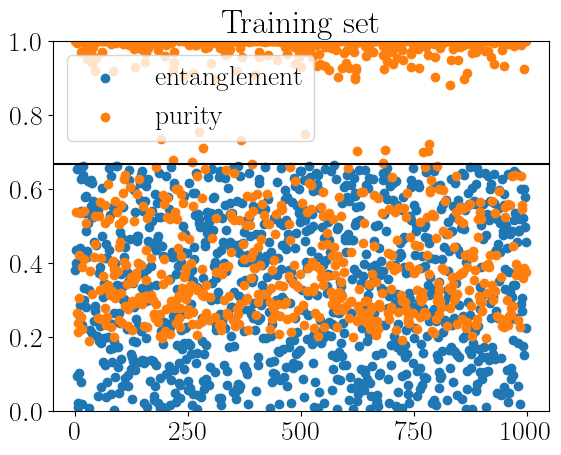

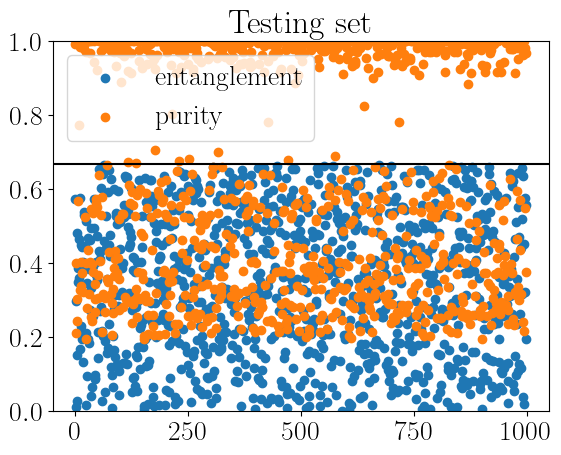

In [17]:
perm_train = permutation(len(labels_train))
perm_test = permutation(len(labels_test))

n_train_trunc = 1000
n_test_trunc = 1000

labels_train_trunc = labels_train[perm_train][:n_train_trunc]
labels_test_trunc = labels_test[perm_test][:n_test_trunc]
dms_train_trunc = dms_train[perm_train][:n_train_trunc]
dms_test_trunc = dms_test[perm_test][:n_test_trunc]

purities_test_trunc = array([trace(dm@dm).real for dm in dms_test_trunc])

plt.scatter(arange(n_train_trunc), labels_train_trunc, label="entanglement")
plt.scatter(arange(n_train_trunc), [trace(dm@dm).real for dm in dms_train_trunc], label="purity")
plt.axhline(2/3, color="black")
plt.title("Training set")
plt.ylim(0, 1)
plt.legend()
plt.show()

plt.scatter(arange(n_test_trunc), labels_test_trunc, label="entanglement")
plt.scatter(arange(n_test_trunc), [trace(dm@dm).real for dm in dms_test_trunc], label="purity")
plt.axhline(2/3, color="black")
plt.title("Testing set")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [19]:
""" parallel L """

if __name__ == '__main__':
    
    def compute_L_i(i):
        sleep(10/(i + 1)) # retarded, but prints pretty
        print("\t i = %d" %i)
        L_i = zeros(n_pars)
        dm_train_c = reduce(kron, [dms_train_trunc[i]]*n_copies)
        for j in range(n_pars):
            op_loc = dm_train_c@ansatz[j]
            L_i[j] = trace(op_loc).real
        return L_i

    print("Computing L:")
    time_qr_start = time()
    with Pool() as pool: 
        L = array(pool.map(compute_L_i, [i for i in range(n_train_trunc)]))
    time_qr_finish = time() - time_qr_start
    print("\nComputing L: completed in %.2f s" %time_qr_finish)

Computing L:
	 i = 210
	 i = 168
	 i = 126
	 i = 84
	 i = 42
	 i = 0
	 i = 211
	 i = 85
	 i = 127
	 i = 169
	 i = 43
	 i = 1
	 i = 212
	 i = 128
	 i = 86
	 i = 170
	 i = 44
	 i = 2
	 i = 213
	 i = 171
	 i = 87
	 i = 129
	 i = 45
	 i = 3
	 i = 172
	 i = 214
	 i = 130
	 i = 88
	 i = 46
	 i = 4
	 i = 173
	 i = 131
	 i = 215
	 i = 89
	 i = 47
	 i = 5
	 i = 174
	 i = 132
	 i = 216
	 i = 90
	 i = 48
	 i = 6
	 i = 133
	 i = 175
	 i = 217
	 i = 91
	 i = 49
	 i = 7
	 i = 134
	 i = 176
	 i = 218
	 i = 92
	 i = 50
	 i = 8
	 i = 135
	 i = 177
	 i = 219
	 i = 93
	 i = 51
	 i = 9
	 i = 136
	 i = 178
	 i = 220
	 i = 94
	 i = 52
	 i = 10
	 i = 137
	 i = 179
	 i = 221
	 i = 95
	 i = 53
	 i = 11
	 i = 138
	 i = 180
	 i = 222
	 i = 96
	 i = 54
	 i = 139
	 i = 12
	 i = 181
	 i = 97
	 i = 223
	 i = 55
	 i = 140
	 i = 13
	 i = 182
	 i = 98
	 i = 224
	 i = 56
	 i = 141
	 i = 183
	 i = 14
	 i = 99
	 i = 225
	 i = 57
	 i = 142
	 i = 184
	 i = 15
	 i = 226
	 i = 100
	 i = 58
	 i = 143
	 i = 185
	 i = 16
	 i = 2

In [1]:
6139.82/60/60

1.7055055555555554

In [28]:
# """ sequential L"""

# time_start = time()
# L = zeros((n_train, n_pars))
# S = zeros((n_train, n_pars, n_pars))
# for i in range(n_train):
#     print("Computing L and S: i=%d" %i, end="\r")
#     dm_train_c = reduce(kron, [dms_train[i]]*n_copies)
#     for j in range(n_pars):
#         op_loc = dm_train_c@ansatz[j]
#         L[i][j] = trace(op_loc).real
#         for k in range(n_pars):
#             print("Computing L and S: i=%d | j=%d | k=%d" %(i, j, k), end="\r")
#             S[i][j][k] = trace(op_loc@ansatz[k]).real
# time_finish = time() - time_start
# print("Computing L and S: completed in %.2f s" %time_finish, end="\r")

In [20]:
time_opt_start = time()
fvals, result = train_obs_L(labels_train_trunc, ansatz, L=L,
                            n_copies=n_copies, x0=None, method=method, 
                            options=options, save_data=False, file_name=None)
time_opt_finish = time() - time_opt_start
print("\n\nOptimization finished in", time_opt_finish)
print("Cost:", result.fun)
print(result.message)
pars = result.x

			Iteration: 27 | Cost: 0.65191581 | Time passed: 1 s

Optimization finished in 1.0817162990570068
Cost: 0.6519158142714605
Optimization terminated successfully.


In [21]:
""" parallel inferrence """

if __name__ == '__main__':

    def infer_i(i):
        sleep(10/(i + 1)) # retarded, but prints pretty
        print("\t i = %d" %i)
        dm_test_c = reduce(kron, [dms_test_trunc[i]]*n_copies)
        expec = trace(H@dm_test_c).real
        disp = trace(H_sq@dm_test_c).real
        return expec, disp

    print("Computing expectations and variances on the testing set")
    time_infer_start = time()
    H = sparse.csr_array(sum([par*op for par, op in zip(pars, ansatz)]))
    H_sq = sparse.csr_array(H@H)
    with Pool() as pool: 
        expecs_test_trunc, disps_test_trunc = array(pool.map(infer_i, [i for i in range(n_test_trunc)])).T
    time_infer_finish = time() - time_infer_start
    print("\nFinished in %.2f s" %time_infer_finish)

Computing expectations and variances on the testing set
	 i = 210
	 i = 168
	 i = 126
	 i = 84
	 i = 42
	 i = 0
	 i = 211
	 i = 169
	 i = 85
	 i = 43
	 i = 127
	 i = 212
	 i = 86
	 i = 170
	 i = 44
	 i = 128
	 i = 1
	 i = 213
	 i = 87
	 i = 171
	 i = 129
	 i = 45
	 i = 2
	 i = 214
	 i = 172
	 i = 88
	 i = 130
	 i = 46
	 i = 3
	 i = 215
	 i = 89
	 i = 173
	 i = 131
	 i = 47
	 i = 216
	 i = 4
	 i = 90
	 i = 174
	 i = 132
	 i = 48
	 i = 217
	 i = 91
	 i = 175
	 i = 133
	 i = 49
	 i = 5
	 i = 218
	 i = 92
	 i = 176
	 i = 134
	 i = 50
	 i = 6
	 i = 219
	 i = 93
	 i = 135
	 i = 177
	 i = 51
	 i = 7
	 i = 220
	 i = 178
	 i = 94
	 i = 136
	 i = 52
	 i = 8
	 i = 221
	 i = 179
	 i = 95
	 i = 137
	 i = 53
	 i = 9
	 i = 222
	 i = 180
	 i = 96
	 i = 138
	 i = 54
	 i = 10
	 i = 223
	 i = 181
	 i = 97
	 i = 139
	 i = 55
	 i = 11
	 i = 224
	 i = 140
	 i = 182
	 i = 98
	 i = 56
	 i = 12
	 i = 225
	 i = 141
	 i = 99
	 i = 183
	 i = 57
	 i = 13
	 i = 226
	 i = 142
	 i = 184
	 i = 100
	 i = 58
	 i = 14
	 

In [47]:
# """ sequential inferrence """
# time_infer_start = time()
# expecs_test_trunc, disps_test_trunc = aux_info(dms_test_trunc, labels_test_trunc, pars, ansatz, n_copies=n_copies)
# time_infer_finish = time() - time_infer_start
# print("\n\nInference finished in", time_infer_finish)

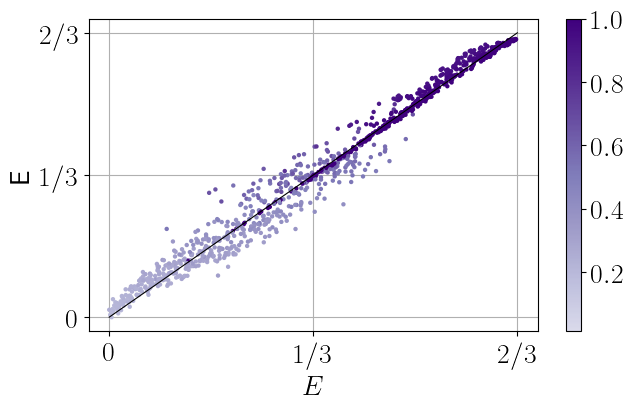

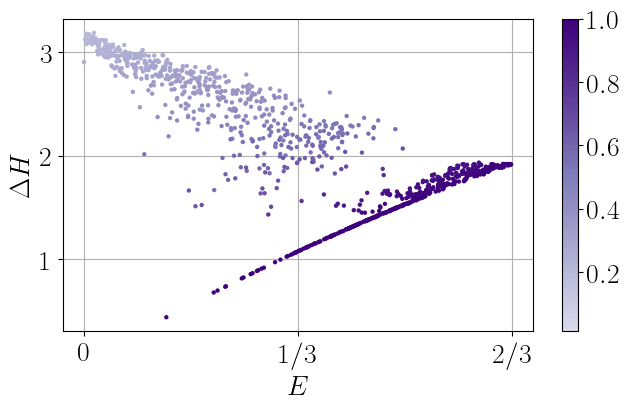

In [24]:
path = ""
file_name = "two_qutrits-lin_ent-T=%d-M=%d" %(n_train_trunc, n_pars)
add_info = "-no_disp_reg"

np.save(path + file_name + add_info + "-L", L)
# np.save(path + file_name + add_info + "-S", S)
np.save(path + file_name + add_info + "-labels_train_trunc", labels_train_trunc)
np.save(path + file_name + add_info + "-dms_train_trunc", dms_train_trunc)
np.save(path + file_name + add_info + "-expecs_test_trunc", expecs_test_trunc)
np.save(path + file_name + add_info + "-disps_test_trunc", disps_test_trunc)
np.save(path + file_name + add_info + "-ansatz", array(ansatz))

cmap_name = "Purples"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.25, 1., cmap.N))
cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

plt.figure(figsize=(7, 4.5))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_test_trunc, expecs_test_trunc, c=purities_test_trunc, cmap=cmap, s=10, edgecolor='none')
plt.plot(linspace(0, 2/3), linspace(0, 2/3), linestyle="-", linewidth=0.8, color="black")
plt.xticks([0, 1/3, 2/3], [r"$0$", r"$1/3$", r"$2/3$"])
plt.yticks([0, 1/3, 2/3], [r"$0$", r"$1/3$", r"$2/3$"])
plt.xlabel(r"$E$")
plt.ylabel(r"$\mathsf{E}$")
plt.colorbar()
plt.clim(1/(dim**n_inp)**2, 1)
plt.grid()
plt.tight_layout()
plt.savefig(path + file_name + add_info + "-expec" + ".pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 4.5))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_test_trunc, disps_test_trunc, c=purities_test_trunc, cmap=cmap, s=10, edgecolor='none')
plt.xticks([0, 1/3, 2/3], [r"$0$", r"$1/3$", r"$2/3$"])
plt.xlabel(r"$E$")
plt.ylabel(r"$\Delta H$")
# plt.title(r"$c = %d$, $l = %d$, $E = %f$" %(n_copies, n_layers, sum_err_test_trunc))
plt.colorbar()
plt.clim(1/(dim**n_inp)**2, 1)
plt.grid()
plt.tight_layout()
plt.savefig(path + file_name + add_info + "-disp" + ".pdf", transparent=True, bbox_inches='tight')
plt.show()